# AI Usage Documentation

### 1. AI Tools Used

- **Claude Code**  - Claude Opus 5.5 (2026/09/29)

### 2. Tasks Assisted

- **理解作業**：解讀作業規定（陣列格式、繳交方式、AI 使用紀錄的要求）。
- **量測參考圖**：以 [參考圖](https://x.com/kamisumi102315/status/2101991340888453198/photo/2) 為目標，用程式量測座標與顏色，包括加上座標格線、依顏色分區找出臉／頭髮／陰影的邊界，以及取樣顏色。
- **設計繪圖工具**：用 NumPy 寫出一組繪圖函式：
  - SDF 形狀：圓、橢圓、膠囊、多邊形。
  - 抗鋸齒 alpha 混色。
  - Catmull-Rom／Bézier 曲線。
  - 髮束與花瓣的掃掠（sweep）形狀。
  - 漸層與遮罩。
- **迭代修正**：以「繪師由後往前疊圖層」的順序作畫，每一版都和參考圖比對（並排比較、把參考圖邊緣線疊在自己的圖上、像素誤差熱圖），再修正位置、形狀與配色。
- **整理成 notebook**：把結果整理成本 notebook，並撰寫每個步驟的公式說明。

### 3. Prompts and Interactions

實際使用的 Prompt（依時間順序）：

1. 「說明一下這作業要幹嘛」：先請 AI 解釋作業要求。
2. 「根據 ref.png 去繪製圖像，以繪師的角度去用 draw function or helpful function 重複疊代直到完成，先不要處理 Cell 1 的要求」：指定參考圖，要求建立繪圖函式並反覆迭代。
3. 「你負責用 notebook 我自己跑跑看」：中途調整分工，AI 只負責寫 notebook，由我自己執行。
4. 「應該是每一步都要 jupyter notebook 的 display 不要一次顯示出來，然後加入 Cell 1 的東西」：看過第一版後，要求改成每個繪製步驟各自顯示畫面，並補上本紀錄。

**有沒有調整問題：** 有。第一版把所有步驟的縮圖拼成一張圖、最後才一次顯示，看不出逐步作畫的過程，所以我要求改成每個 cell 各自 display。另外也調整了分工方式（改由我自己執行 notebook）。

### 4. Learning and Adaptation

**學到的觀念：**

- **SDF 表示形狀**：$d<0$ 在內部。用 $\alpha=\operatorname{clip}(0.5-d,0,1)$ 就能得到抗鋸齒的邊緣，不需要逐一判斷像素。
- **布林運算**：交集用 $\max(d_1,d_2)$、聯集用 $\min$，例如帽子就是圓和半平面的交集。
- **alpha 混色**：$C\leftarrow C+(c-C)\alpha$，這其實就是繪圖軟體裡「圖層由後往前疊」的原理。
- **遮罩**：先記錄「頭髮在哪裡」，之後的陰影只畫在頭髮遮罩內，陰影形狀就不必精準對齊頭髮邊緣。
- **NumPy 技巧**：
  - `np.mgrid` 產生座標網格。
  - broadcasting 對整張影像一次計算。
  - 只在 bounding box 內計算，加速繪圖。
  - `np.pad`／切片做遮罩平移。

**過程中的除錯與調整：**

- **邊界補值**：遮罩平移時畫面外補 0，左邊緣多出一條不自然的色帶，改成 `np.pad(mode='edge')` 延伸邊緣值後修正。
- **環境光範圍**：加上「越往下越暗」的環境光後，眼睛也被染灰。原因是頭髮遮罩包含了臉後方被擋住的區域；改成畫完臉之後，從頭髮遮罩中扣掉臉（`hair *= 1 - face`）。
- **漸層接縫**：環境光把粉紅髮尾也染色，在 y=720 出現一條明顯的接縫；改成在進入髮尾前平滑淡出。
- **瀏海形狀**：一開始瀏海是一整塊多邊形，和參考圖相比太平；改成「基底＋一撮一撮的尖髮束」，每撮再加一側陰影。
- **右側頭髮**：原本用幾條細髮束，中間露出臉；對照參考圖後改成一整片、下緣是鋸齒的白髮。
- **量化比較**：用參考圖和自己的畫計算平均像素誤差，作為調整是否有效的依據（約從 17.4 降到 16.1）。

# 作業一：用 NumPy 繪製 Q 版角色

以繪師「由後往前疊圖層」的方式，用純 NumPy 在 `1024 × 1024 × 3` 的畫布上畫出一張 Q 版角色（參考圖來源：<https://x.com/kamisumi102315/status/2101991340888453198/photo/2>；座標與顏色由參考圖量測後，以程式描繪）。

**核心方法：SDF（Signed Distance Field）＋ 抗鋸齒 alpha 混色**

- 形狀以 SDF 描述：$d(x,y)<0$ 為內部、$d>0$ 為外部，$|d|$ 為到邊界的像素距離。
- 覆蓋率（抗鋸齒）：$\alpha=\operatorname{clip}(0.5-d/s,\ 0,\ 1)$，$s$ 為柔邊寬度（預設 1 px）。
- 疊色（over）：$C \leftarrow C + (c-C)\,\alpha$。
- 畫布以 `float32`、值域 $[0,1]$ 計算，最後轉成 `np.uint8`。

In [16]:
from collections.abc import Callable
from typing import Any

import numpy as np
from numpy.typing import NDArray
from PIL import Image

Arr = NDArray[np.float32]
Pts = NDArray[np.float64]
Pt = tuple[float, float]
SDF = Callable[[Arr, Arr], Arr]
ColorFn = Callable[[Arr, Arr], Arr]
Color = str | float | tuple[float, ...] | Arr | ColorFn

H: int = 1024
W: int = 1024
YY, XX = np.mgrid[0:H, 0:W].astype(np.float32) + 0.5   # 像素中心座標
canvas: Arr = np.zeros((H, W, 3), np.float32)


def rgb(h: str) -> Arr:
    """'#rrggbb' → [0,1] 的 RGB 向量。"""
    h = h.lstrip('#')
    return np.array([int(h[i:i + 2], 16) for i in (0, 2, 4)], np.float32) / 255

## 1. SDF 基本形狀

| 形狀 | SDF |
|---|---|
| 圓 | $d=\lVert p-c\rVert-r$ |
| 橢圓（近似） | $d\approx(\lVert R(p-c)\oslash(r_x,r_y)\rVert-1)\cdot\min(r_x,r_y)$ |
| 膠囊（線段＋半徑） | $t=\operatorname{clip}\!\big(\tfrac{(p-a)\cdot(b-a)}{\lVert b-a\rVert^2},0,1\big),\ d=\lVert p-a-t(b-a)\rVert-r$ |
| 多邊形 | $\lvert d\rvert=\min_i \operatorname{dist}(p,\text{edge}_i)$，正負號由射線交點奇偶（even-odd）判定 |

布林運算：交集 $\max(d_1,d_2)$、聯集 $\min(d_1,d_2)$、差集 $\max(d_1,-d_2)$。

In [17]:
def sd_circle(x: Arr, y: Arr, cx: float, cy: float, r: float) -> Arr:
    return np.hypot(x - cx, y - cy) - r


def sd_ellipse(x: Arr, y: Arr, cx: float, cy: float, rx: float, ry: float, ang: float = 0.0) -> Arr:
    c, s = np.cos(np.radians(ang)), np.sin(np.radians(ang))
    u = ((x - cx) * c + (y - cy) * s) / rx
    v = (-(x - cx) * s + (y - cy) * c) / ry
    return (np.hypot(u, v) - 1) * min(rx, ry)


def sd_capsule(x: Arr, y: Arr, p0: Pt, p1: Pt, r: float) -> Arr:
    ax, ay = x - p0[0], y - p0[1]
    bx, by = p1[0] - p0[0], p1[1] - p0[1]
    t = np.clip((ax * bx + ay * by) / (bx * bx + by * by), 0, 1)
    return np.hypot(ax - bx * t, ay - by * t) - r


def sd_polygon(x: Arr, y: Arr, P: Pts) -> Arr:
    d = np.full(x.shape, np.inf, np.float32)
    inside = np.zeros(x.shape, bool)
    for (x0, y0), (x1, y1) in zip(P, np.roll(P, -1, axis=0)):
        ex, ey = x1 - x0, y1 - y0
        wx, wy = x - x0, y - y0
        t = np.clip((wx * ex + wy * ey) / max(ex * ex + ey * ey, 1e-9), 0, 1)
        d = np.minimum(d, (wx - ex * t) ** 2 + (wy - ey * t) ** 2)
        inside ^= ((y0 > y) != (y1 > y)) & (x < (x1 - x0) * (y - y0) / (y1 - y0 + 1e-9) + x0)
    return np.where(inside, -1, 1) * np.sqrt(d)

## 2. 路徑工具：控制點 → 多邊形

- **Catmull-Rom**：通過所有控制點的平滑閉合曲線（頭髮輪廓、脖子陰影）。
- **二次 Bézier**：$B(t)=(1-t)^2P_0+2(1-t)tP_1+t^2P_2$。
- `curvy`：每條邊換成 Bézier 弧、角保持尖銳 → 瀏海的鋸齒邊。
- `sweep`：沿 Bézier 脊線 $S(t)$，以單位法向量 $n(t)$ 張開半寬 $h(t)$，輪廓為 $S\pm h\,n$。
  - `strand`（髮束）：$h(t)=\tfrac{w}{2}(1-t)^p$，根部寬、尾端尖；$p<1$ 較飽滿。
  - `leaf`（花瓣）：$h(t)=\tfrac{w}{2}\sin(\pi t^k)^r$，$k=\ln 0.5/\ln(\text{peak})$ 使最寬處落在 `peak`。

In [18]:
def catmull(pts: list[Pt], n: int = 10) -> Pts:
    """閉合 Catmull-Rom 曲線，每段取 n 點。"""
    P = np.asarray(pts, float)
    m = len(P)
    t = np.linspace(0, 1, n, endpoint=False)[:, None]
    out: list[Pts] = []
    for i in range(m):
        p0, p1, p2, p3 = P[(i - 1) % m], P[i], P[(i + 1) % m], P[(i + 2) % m]
        out.append(0.5 * (2 * p1 + (-p0 + p2) * t + (2 * p0 - 5 * p1 + 4 * p2 - p3) * t ** 2
                          + (-p0 + 3 * p1 - 3 * p2 + p3) * t ** 3))
    return np.vstack(out)


def bezier(p0: Pt, p1: Pt, p2: Pt, n: int = 24) -> Pts:
    t = np.linspace(0, 1, n)[:, None]
    a, b, c = (np.asarray(p, float) for p in (p0, p1, p2))
    return (1 - t) ** 2 * a + 2 * (1 - t) * t * b + t ** 2 * c


def curvy(pts: list[Pt], bow: float = 0.1, n: int = 14) -> Pts:
    """多邊形的每條邊改成弧線（角仍是尖的）；bow>0 往外鼓。"""
    P = np.asarray(pts, float)
    out: list[Pts] = []
    for a, b in zip(P, np.roll(P, -1, axis=0)):
        e = b - a
        c = (a + b) / 2 + bow * np.array([e[1], -e[0]])
        out.append(bezier(tuple(a), tuple(c), tuple(b), n)[:-1])
    return np.vstack(out)


def sweep(p0: Pt, ctrl: Pt, p1: Pt, half_fn: Callable[[Pts], Pts]) -> Pts:
    """沿貝茲脊線掃出形狀，half_fn(t) 決定每一點的半寬。"""
    S = bezier(p0, ctrl, p1, 40)
    d = np.gradient(S, axis=0)
    nrm = np.stack([-d[:, 1], d[:, 0]], 1) / np.linalg.norm(d, axis=1, keepdims=True)
    half = half_fn(np.linspace(0, 1, len(S))[:, None])
    return np.vstack([S + nrm * half, (S - nrm * half)[::-1]])


def strand(root: Pt, ctrl: Pt, tip: Pt, w: float, power: float = 1.0) -> Pts:
    """一撮頭髮：根部寬 w，沿曲線收成尖端。"""
    return sweep(root, ctrl, tip, lambda t: 0.5 * w * (1 - t) ** power)


def leaf(p0: Pt, p1: Pt, w: float, ctrl: Pt | None = None, peak: float = 0.45, round_: float = 0.6) -> Pts:
    """花瓣／葉片：兩端尖、最寬處在 peak。"""
    if ctrl is None:
        ctrl = ((p0[0] + p1[0]) / 2, (p0[1] + p1[1]) / 2)
    k = np.log(0.5) / np.log(peak)
    return sweep(p0, ctrl, p1, lambda t: 0.5 * w * np.sin(np.pi * t ** k) ** round_)

## 3. 上色工具

- `paint`：只在 bounding box 內計算 SDF（加速），依 $\alpha$ 疊色。
  - `clip`：$\alpha$ 再乘上遮罩 → 陰影只畫在頭髮上。
  - `target`：不上色，只累積遮罩 $m\leftarrow\max(m,\alpha)$。
- `vgrad` / `radial`：顏色是座標的函數；`vgrad` 用 smoothstep $t^2(3-2t)$。
- `shifted`：遮罩平移 → 做投影（瀏海在臉上的細陰影）。
- `preview`：每個繪製步驟結束時顯示當下畫面（512×512 預覽）。

In [19]:
def as_color(c: Color, x: Arr, y: Arr) -> Arr:
    if callable(c):
        return c(x, y)
    if isinstance(c, str):
        return rgb(c)
    return np.asarray(c, np.float32)


def bbox_of(P: Pts, pad: float = 2) -> tuple[int, int, int, int]:
    x0, y0 = np.floor(P.min(0) - pad).astype(int)
    x1, y1 = np.ceil(P.max(0) + pad).astype(int)
    return max(x0, 0), max(y0, 0), min(x1, W), min(y1, H)


def paint(sdf: SDF, box: tuple[int, int, int, int], color: Color, alpha: float = 1.0,
          clip: Arr | None = None, soft: float = 1.0, target: Arr | None = None) -> None:
    """在 box 範圍內依 SDF 抗鋸齒填色；clip 限制在遮罩內；target 只累積遮罩。"""
    x0, y0, x1, y1 = box
    if x1 <= x0 or y1 <= y0:
        return
    x, y = XX[y0:y1, x0:x1], YY[y0:y1, x0:x1]
    a = np.clip(0.5 - sdf(x, y) / soft, 0, 1) * alpha
    if clip is not None:
        a = a * clip[y0:y1, x0:x1]
    if target is not None:
        target[y0:y1, x0:x1] = np.maximum(target[y0:y1, x0:x1], a)
        return
    region = canvas[y0:y1, x0:x1]
    region += (as_color(color, x, y) - region) * a[..., None]


def poly(P: Pts, color: Color, **kw: Any) -> None:
    paint(lambda x, y: sd_polygon(x, y, P), bbox_of(P), color, **kw)


def ellipse(cx: float, cy: float, rx: float, ry: float, color: Color, ang: float = 0, **kw: Any) -> None:
    r = max(rx, ry) + 3
    paint(lambda x, y: sd_ellipse(x, y, cx, cy, rx, ry, ang),
          (max(int(cx - r), 0), max(int(cy - r), 0), min(int(cx + r), W), min(int(cy + r), H)), color, **kw)


def capsule(p0: Pt, p1: Pt, r: float, color: Color, **kw: Any) -> None:
    paint(lambda x, y: sd_capsule(x, y, p0, p1, r), bbox_of(np.array([p0, p1], float), r + 3), color, **kw)


def lock(root: Pt, ctrl: Pt, tip: Pt, w: float, color: Color, power: float = 1.0, **kw: Any) -> None:
    poly(strand(root, ctrl, tip, w, power), color, **kw)


def stroke(pts: list[Pt], r: float, color: Color, **kw: Any) -> None:
    """折線筆刷：多段膠囊的聯集（min）。"""
    P = np.asarray(pts, float)

    def sdf(x: Arr, y: Arr) -> Arr:
        return np.min([sd_capsule(x, y, tuple(a), tuple(b), r) for a, b in zip(P[:-1], P[1:])], axis=0)
    paint(sdf, bbox_of(P, r + 3), color, **kw)


def new_mask() -> Arr:
    return np.zeros((H, W), np.float32)


def fill_mask(m: Arr, color: Color) -> None:
    """整張遮罩 m 當作 alpha 疊色。"""
    paint(lambda x, y: np.zeros_like(x) - 1, (0, 0, W, H), color, clip=m)


def both(P: Pts, color: Color, mask: Arr) -> None:
    """畫到畫布，同時記進遮罩。"""
    poly(P, color)
    poly(P, 0, target=mask)


def shifted(mask: Arr, dx: int, dy: int) -> Arr:
    """遮罩平移 (dx, dy)，畫面外以邊緣值延伸。"""
    p = max(abs(dx), abs(dy))
    m = np.pad(mask, p, mode='edge')
    return m[p - dy:p - dy + H, p - dx:p - dx + W]


def vgrad(c0: str, c1: str, y0: float, y1: float) -> ColorFn:
    """垂直漸層：y0 以上為 c0，y1 以下為 c1。"""
    a, b = rgb(c0), rgb(c1)

    def f(x: Arr, y: Arr) -> Arr:
        t = np.clip((y - y0) / (y1 - y0), 0, 1)
        return a + (b - a) * (t * t * (3 - 2 * t))[..., None]
    return f


def radial(cx: float, cy: float, c0: str, c1: str, r0: float, r1: float) -> ColorFn:
    """放射狀漸層：距中心 r0 內為 c0，r1 外為 c1。"""
    a, b = rgb(c0), rgb(c1)

    def f(x: Arr, y: Arr) -> Arr:
        t = np.clip((np.hypot(x - cx, y - cy) - r0) / (r1 - r0), 0, 1)
        return a + (b - a) * t[..., None]
    return f


def to_uint8(c: Arr) -> NDArray[np.uint8]:
    return (np.clip(c, 0, 1) * 255 + 0.5).astype(np.uint8)


def preview() -> Image.Image:
    """目前畫面的 512×512 預覽（每 2 px 取 1 px），放在 cell 最後一行由 Jupyter 顯示。"""
    return Image.fromarray(to_uint8(canvas[::2, ::2]))

## 4. 調色盤

顏色取樣自參考圖。

In [20]:
BG = '#17151a'
HAT_IN, HAT_RIM = '#21232f', '#2e2e3f'
WHITE = '#f2f2fa'                                   # 頭髮亮部
LAV, LAV2, LAV_S = '#cdcee9', '#e3e2f2', '#d5d6ed'  # 頭髮暗部／環境光／陰影髮束
PINK, PINK_D = '#f589ad', '#b9507a'
FACE, FACE_SH, NECK = '#fbf0f4', '#dfc6d4', '#cdb5c5'
BLUSH, INK = '#f9c9d4', '#1f1c23'
NAVY, NAVY_L, NAVY_D = '#2a2f48', '#3d4260', '#1d2033'
JACKET, SHIRT, LINE = '#25273a', '#e8e9f4', '#d5d7ea'
STAMEN, BUD = '#ef91b1', '#fca5c7'

## 5. 背景與帽子

帽子 = 外圓（亮邊）疊上內圓（暗面），兩者都用 `cut` 以半平面交集 $\max(d,\ d_{\text{plane}})$ 裁掉被頭髮擋住的部分。
半平面 SDF：$d_{\text{plane}}=\dfrac{(p-p_0)\cdot n}{\lVert n\rVert}$。

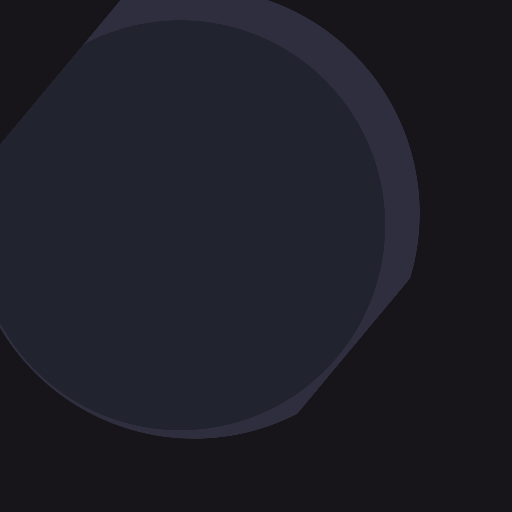

In [21]:
canvas[:] = rgb(BG)


def cut(d: Arr, x: Arr, y: Arr) -> Arr:
    """帽子只露出頭頂上方與右側。"""
    d = np.maximum(d, ((x - 850) * 240 + (y - 520) * 200) / np.hypot(240, 200))
    return np.maximum(d, -((x - 240) * 60 + y * 50) / np.hypot(60, 50))


paint(lambda x, y: cut(sd_circle(x, y, 388, 426, 451), x, y), (0, 0, W, H), HAT_RIM)
paint(lambda x, y: cut(sd_circle(x, y, 360, 450, 410), x, y), (0, 0, W, H), HAT_IN)
preview()

## 6. 身體：外套、襯衫、胸針

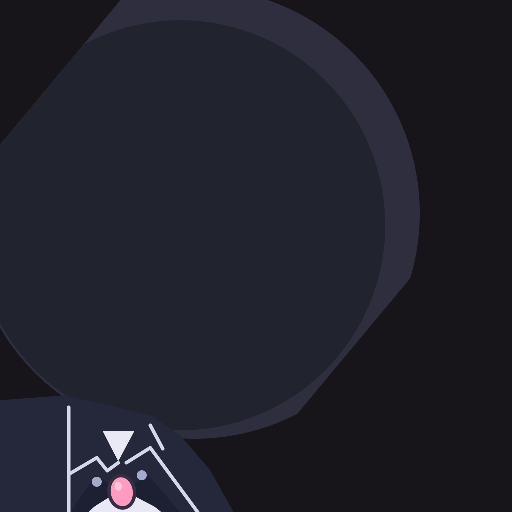

In [22]:
poly(np.array([(0, 800), (130, 790), (300, 830), (360, 870), (420, 940), (470, 1030), (0, 1030)], float), JACKET)
poly(np.array([(170, 1030), (243, 960), (330, 1030)], float), SHIRT)                  # 襯衫下擺
poly(np.array([(205, 862), (268, 862), (236, 922)], float), SHIRT)                    # 襯衫領尖
poly(np.array([(190, 950), (240, 980), (170, 1024), (140, 1024)], float), NAVY_D)     # 領結左
poly(np.array([(296, 950), (246, 980), (330, 1024), (360, 1024)], float), NAVY_D)     # 領結右
stroke([(137, 814), (137, 1024)], 3.5, LINE)                                           # 左領邊線
stroke([(137, 948), (193, 915), (214, 941), (236, 925)], 3.5, LINE)                    # 翻領缺口
stroke([(252, 925), (300, 895), (395, 1024)], 3.5, LINE)                               # 右領邊線
stroke([(300, 850), (325, 897)], 3.5, LINE)
ellipse(193, 963, 10, 10, '#a4aacc')                                                  # 珍珠
ellipse(283, 950, 10, 10, '#a4aacc')
ellipse(243, 983, 29, 36, '#342d43', ang=-8)                                          # 胸針框
ellipse(243, 983, 22, 29, '#fd9bc1', ang=-8)
ellipse(236, 972, 7, 9, '#ffc6dc', ang=-8)                                            # 高光
preview()

## 7. 後髮：圓頂、頭頂暗面、粉紅髮尾

- 頭頂暗面：`rim = dome · (1 − inner)`，即圓頂扣掉受光區。
- 髮尾顏色用 `vgrad` 由白漸變到粉紅。
- `hair` 遮罩記錄所有頭髮，之後的陰影只畫在遮罩內。

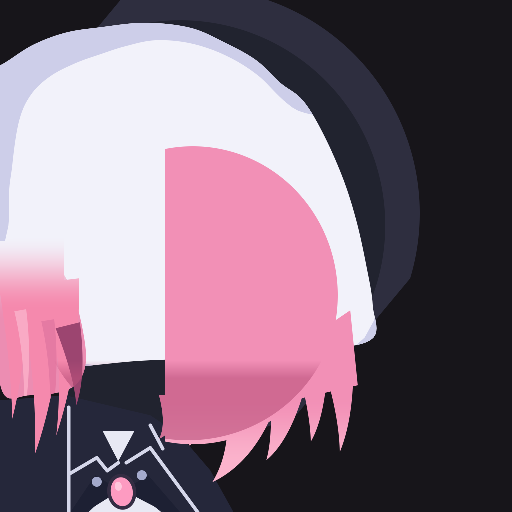

In [23]:
hair = new_mask()
dome = new_mask()
dome_P = catmull([(-40, 140), (0, 130), (64, 90), (130, 65), (200, 54), (290, 45), (380, 55), (450, 85),
                  (512, 120), (560, 165), (605, 200), (645, 265), (685, 355), (712, 440), (732, 530),
                  (745, 610), (740, 680), (600, 700), (300, 720), (0, 720), (-40, 500)])
both(dome_P, WHITE, dome)
hair[:] = dome
inner = new_mask()                                                                    # 頭頂受光區
poly(catmull([(585, 215), (515, 150), (450, 110), (380, 86), (310, 80), (250, 92), (200, 108), (150, 126),
              (100, 152), (62, 188), (38, 240), (24, 330), (18, 430), (40, 700), (700, 700), (720, 300)]),
     0, target=inner)
rim = dome * (1 - inner)                                                               # 頭頂暗面
fill_mask(rim, LAV)

# 左側粉紅髮尾
pinkL = vgrad(WHITE, PINK, 470, 620)
both(catmull([(0, 520), (120, 540), (170, 690), (150, 770), (60, 790), (0, 770)]), vgrad(WHITE, '#ec8db2', 470, 640), hair)
for root, ctrl, tip, w in [
    ((20, 480), (40, 700), (24, 837), 75),
    ((70, 470), (105, 720), (69, 909), 115),
    ((125, 560), (145, 720), (112, 870), 65),
]:
    both(strand(root, ctrl, tip, w), pinkL, hair)
lock((135, 650), (160, 750), (152, 810), 50, '#9c4570')                                # 暗處的一撮
lock((40, 620), (60, 730), (45, 850), 24, '#f9aac5', clip=hair)                        # 亮部
lock((95, 640), (115, 760), (95, 880), 26, '#e57aa3', clip=hair)

# 臉下方的粉紅髮（在臉後面）
pinkR = vgrad('#f290b6', '#fbb3cc', 790, 930)


def back_sdf(x: Arr, y: Arr) -> Arr:
    """臉下方的髮底色：放大的臉橢圓，只取脖子右側。"""
    return np.maximum(sd_ellipse(x, y, 385, 590, 290, 298), 330 - x)


paint(back_sdf, (300, 280, 700, 900), pinkR)
paint(back_sdf, (300, 280, 700, 900), 0, target=hair)
both(np.array([(480, 770), (700, 620), (715, 770), (520, 815)], float), pinkR, hair)
for root, ctrl, tip, w in [
    ((345, 790), (345, 850), (318, 877), 55),
    ((410, 790), (405, 860), (377, 891), 65),
    ((505, 770), (495, 900), (424, 964), 115),
    ((575, 760), (565, 870), (532, 920), 75),
    ((625, 730), (635, 830), (621, 883), 60),
    ((670, 690), (695, 820), (679, 904), 70),
]:
    both(strand(root, ctrl, tip, w), pinkR, hair)

# 臉在髮上投下的暗影：放大的臉橢圓 ∩ 頭髮，越往下越明顯
fill_mask(hair * np.clip(0.5 - sd_ellipse(XX, YY, 375, 590, 300, 290), 0, 1)
          * np.clip((YY - 720) / 60, 0, 0.6), PINK_D)
preview()

## 8. 臉、腮紅、眼睛

臉是一個大橢圓；畫完後 `hair *= 1 − face`，讓 `hair` 只剩「看得到的頭髮」。眼睛是傾斜的膠囊。

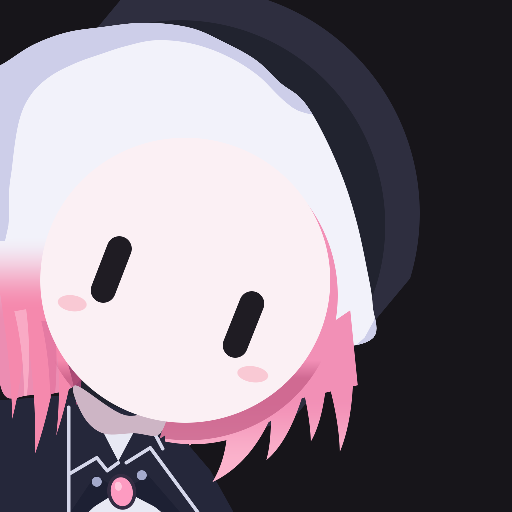

In [24]:
poly(catmull([(150, 770), (250, 830), (330, 815), (318, 868), (268, 866), (205, 866), (165, 830)]), NECK)  # 脖子陰影
face = new_mask()
paint(lambda x, y: sd_ellipse(x, y, 370, 560, 290, 285), (60, 260, 680, 860), FACE)
paint(lambda x, y: sd_ellipse(x, y, 370, 560, 290, 285), (60, 260, 680, 860), 0, target=face)
hair *= 1 - face

ellipse(144, 606, 29, 16, BLUSH, ang=8)
ellipse(505, 748, 31, 16, BLUSH, ang=8)
capsule((238, 497), (206, 580), 25, INK)
capsule((503, 607), (470, 690), 25, INK)
preview()

## 9. 瀏海

一塊鋸齒邊的基底（`curvy`）＋ 四撮垂下的尖髮（`strand`）。

- 瀏海在臉上的細陰影：`face · shifted(bangs, 3, 6)`，也就是把瀏海遮罩往右下平移後與臉取交集。
- 每撮髮束：由白到淡紫的漸層，再疊一條較窄的陰影髮束（clip 在該撮內）。

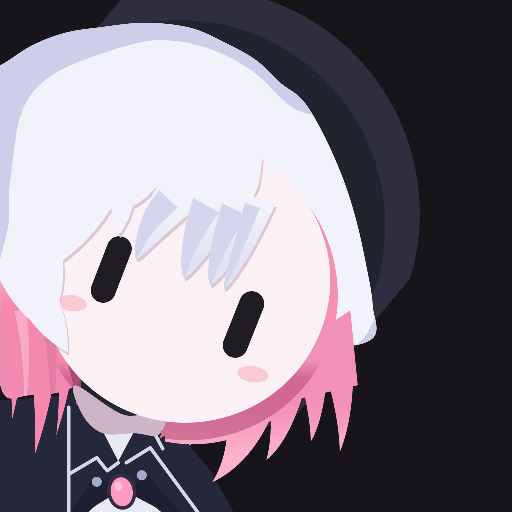

In [25]:
bangs_P = curvy([
    (0, 250), (520, 250), (515, 375), (480, 425), (420, 405), (360, 392), (315, 370), (265, 412),
    (237, 470), (222, 415), (125, 520), (118, 600), (135, 705), (60, 640), (0, 560)], 0.1)
bang_locks: list[tuple[Pt, Pt, Pt, float]] = [   # root, ctrl, tip, width
    ((365, 378), (300, 450), (272, 518), 95),
    ((445, 388), (392, 480), (368, 556), 110),
    ((498, 398), (446, 500), (420, 570), 100),
    ((522, 398), (482, 510), (447, 578), 60),
]
bangs = new_mask()
poly(bangs_P, 0, target=bangs)
for r, c, t, w in bang_locks:
    poly(strand(r, c, t, w, 0.7), 0, target=bangs)

fill_mask(face * shifted(bangs, 3, 6), FACE_SH)
poly(bangs_P, WHITE)
fill_mask(rim * bangs, LAV)
for r, c, t, w in bang_locks:
    P = strand(r, c, t, w, 0.7)
    m = new_mask()
    poly(P, 0, target=m)
    poly(P, vgrad(WHITE, LAV2, 400, 530))
    poly(strand((r[0] - w * 0.3, r[1] + w * 0.2), (c[0] - w * 0.25, c[1] + w * 0.1), t, w * 0.55, 0.7),
         LAV_S, clip=m)
hair = np.maximum(hair, bangs)
preview()

## 10. 右前髮

一大片白髮蓋住臉右側，下緣是鋸齒髮尖；後面夾著一撮淡粉色髮束，最右邊還有一撮往外翹的白髮。

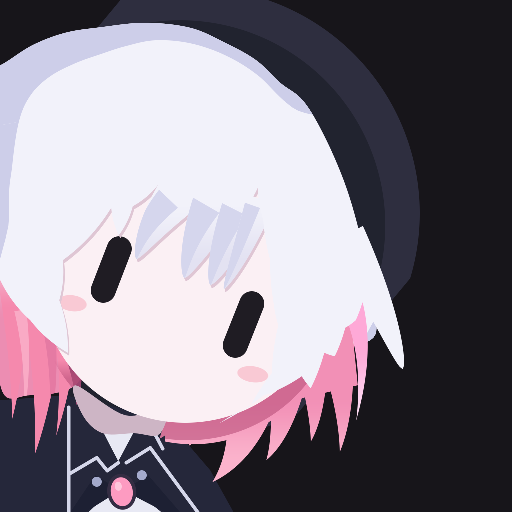

In [26]:
both(strand((700, 600), (740, 700), (712, 840), 46), vgrad('#fea9d7', '#fedaf3', 690, 830), hair)
both(strand((690, 470), (770, 620), (805, 738), 80, 0.6), WHITE, hair)
front_R = curvy([(515, 380), (522, 290), (610, 300), (690, 430), (722, 520), (728, 590), (711, 640), (690, 655),
                 (669, 712), (648, 705), (621, 776), (603, 752), (549, 782), (527, 790), (440, 845),
                 (500, 812), (543, 746), (556, 650), (546, 600), (540, 520), (526, 440)], 0.05)
both(front_R, WHITE, hair)
preview()

## 11. 頭髮陰影

全部 `clip=hair`，只會畫在頭髮上。

1. 環境光：$\alpha=\operatorname{clip}\!\big(\tfrac{y-330}{260},0,0.5\big)\cdot\operatorname{clip}\!\big(\tfrac{600-y}{70},0,1\big)$，越往下越暗，進入粉紅髮尾前淡出。
2. 伸進頭頂暗面的亮髮。
3. 薰衣草色的陰影髮束。

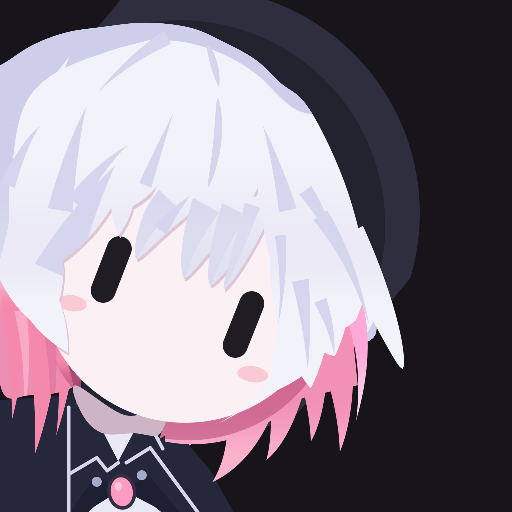

In [27]:
fill_mask(hair * np.clip((YY - 330) / 260, 0, 0.5) * np.clip((600 - YY) / 70, 0, 1), LAV2)
lock((95, 200), (110, 160), (138, 113), 34, WHITE, clip=dome)
lock((190, 150), (245, 100), (305, 78), 30, WHITE, clip=dome)
for root, ctrl, tip, w in [
    ((335, 74), (260, 115), (197, 182), 30),
    ((120, 420), (140, 300), (172, 213), 50),
    ((15, 370), (45, 290), (80, 250), 30),
    ((150, 405), (200, 330), (255, 290), 36),
    ((290, 370), (320, 290), (345, 228), 26),
    ((320, 460), (350, 420), (380, 390), 30),
    ((575, 420), (555, 330), (525, 250), 36),
    ((110, 545), (165, 420), (230, 330), 90),
    ((640, 430), (705, 520), (738, 650), 34),
    ((610, 380), (660, 450), (680, 520), 30),
    ((600, 560), (615, 650), (615, 740), 34),
    ((560, 470), (570, 560), (556, 648), 22),
    ((640, 600), (665, 660), (668, 710), 26),
]:
    lock(root, ctrl, tip, w, LAV_S, clip=hair)
for p0, p1, w, c in [
    ((415, 90), (437, 172), 14, (430, 130)),
    ((435, 195), (415, 375), 16, (442, 290)),
]:
    poly(leaf(p0, p1, w, ctrl=c), LAV_S, clip=hair)
preview()

## 12. 髮夾與緞帶

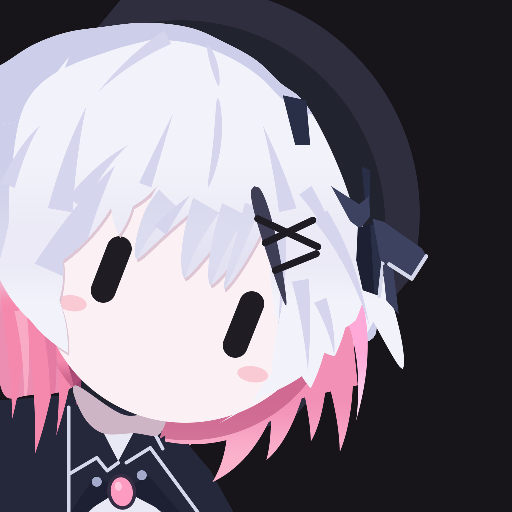

In [28]:
poly(leaf((508, 372), (572, 612), 30, ctrl=(538, 470), peak=0.3), '#3f3e57')         # 緞帶投在頭髮上的暗影
capsule((530, 485), (625, 440), 7, INK)                                               # X 形髮夾
capsule((515, 437), (635, 493), 7, INK)
capsule((550, 540), (632, 507), 7, INK)

poly(np.array([(565, 190), (612, 200), (620, 290), (590, 290)], float), NAVY)
poly(np.array([(723, 333), (740, 340), (740, 432), (732, 432)], float), NAVY)
poly(np.array([(662, 372), (718, 408), (737, 392), (740, 432), (720, 457), (700, 442)], float), NAVY_L)
poly(np.array([(715, 455), (762, 443), (772, 500), (760, 592), (725, 580), (712, 520)], float), NAVY_D)   # 下垂緞帶
poly(np.array([(740, 450), (762, 443), (772, 500), (760, 592), (748, 585)], float), NAVY)
stroke([(768, 500), (758, 592)], 3.5, LINE)
poly(np.array([(765, 530), (785, 530), (797, 628), (772, 600)], float), NAVY_L)
poly(np.array([(745, 437), (767, 443), (843, 496), (853, 512), (823, 560), (777, 530), (760, 520)], float), NAVY_L)  # 右斜緞帶
stroke([(778, 528), (823, 557), (852, 512)], 4, LINE)
preview()

## 13. 花

- 五片花瓣：先用柔邊（`soft=2.5`）畫一層深色，當作花瓣間的暗縫，再疊上從中心往外的放射漸層。
- 花蕊：細長水滴＋圓點。
- 旁邊再畫一個小花苞。

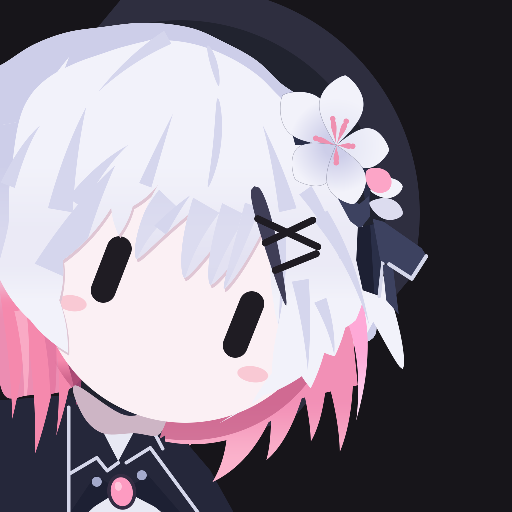

In [29]:
C: Pt = (672, 290)
for tip, w, base in [((565, 190), 92, LAV), ((590, 358), 90, LAV), ((690, 150), 88, '#e6e7f5'),
                     ((778, 300), 80, '#e6e7f5'), ((707, 408), 78, LAV)]:
    P = leaf(C, tip, w, peak=0.58, round_=0.75)
    poly(P, '#3a3d58', soft=2.5)
    poly(P, radial(C[0], C[1], base, WHITE, 25, 95))
for tip in [(692, 242), (665, 237), (631, 276), (705, 292), (672, 325)]:
    poly(leaf(C, tip, 11, peak=0.75, round_=0.6), STAMEN)
    ellipse(tip[0], tip[1], 5.5, 5.5, STAMEN)

poly(leaf((740, 380), (805, 372), 40, peak=0.55), WHITE)                               # 小花苞
poly(leaf((738, 405), (805, 428), 42, peak=0.55), '#dcdcef')
poly(leaf((778, 378), (733, 340), 48, peak=0.45), BUD)
preview()

## 14. 最終影像：`1024 × 1024 × 3`、`np.uint8`

(1024, 1024, 3) uint8


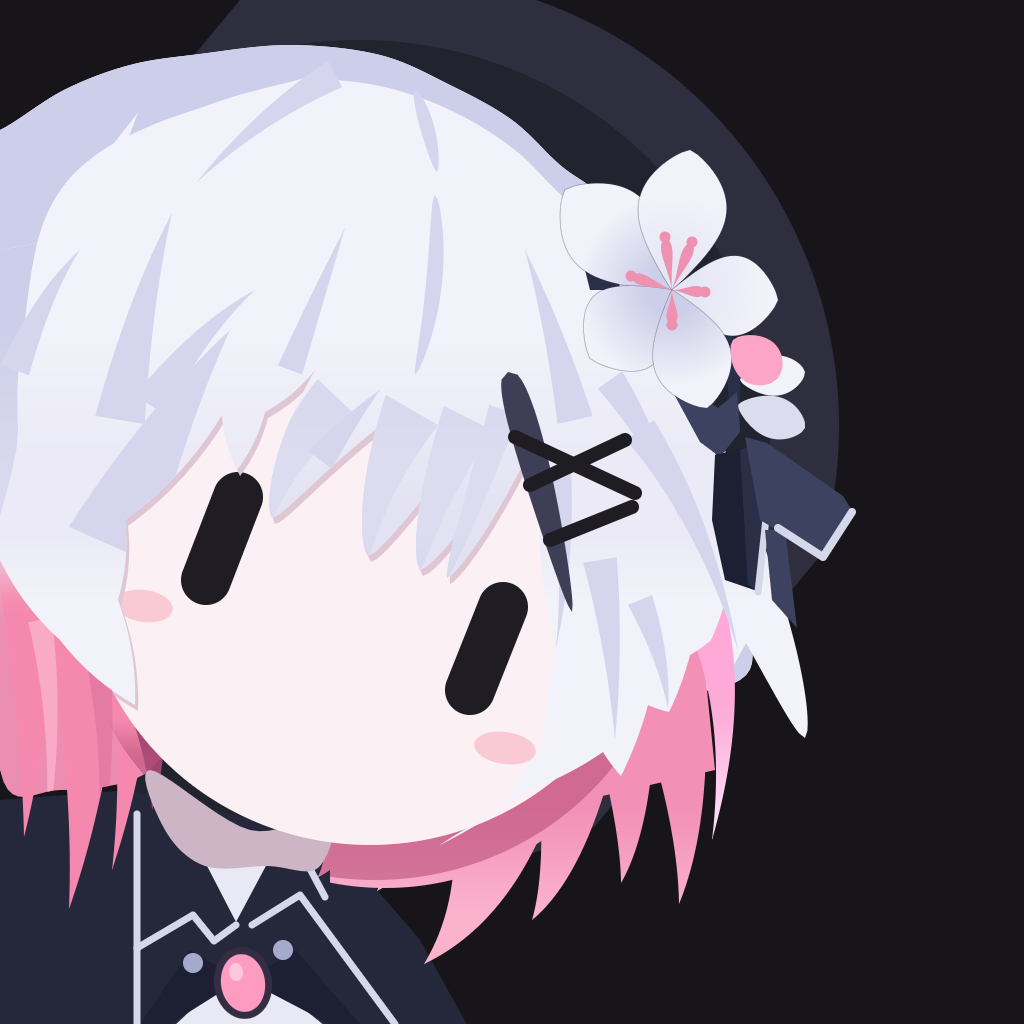

In [30]:
img: NDArray[np.uint8] = to_uint8(canvas)
print(img.shape, img.dtype)
Image.fromarray(img)